In [98]:
# Library import

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import requests
from bs4 import BeautifulSoup

# Plot styling
sns.set_style('ticks')

#### 1. Dataset Loading

**---------- 1. DATASE LOADING ----------**

In [99]:
# Read tracks.csv
tracks = pd.read_csv('../data/kaggle2/tracks.csv')
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


**---------- 2. DATA OVERVIEW ----------**

In [100]:
tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  str    
 1   name              586601 non-null  str    
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  str    
 6   id_artists        586672 non-null  str    
 7   release_date      586672 non-null  str    
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          586672 non-nu

In [101]:
# Checking for null values 
tracks.isnull().sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

**---------- 3. DATA CLEANING ----------**

In [102]:
# --- 1. Handle missing names ---
tracks['name'] = tracks['name'].fillna("Unknown Track")

In [103]:
# --- 2. Dealing with "stringified" lists ---
"""                     ↓
The `artists` and `id_artists` columns were imported as stringified lists. 
Because Python interprets these as literal strings rather than list objects, 
individual elements are not directly accessible for analysis.
"""

# Check 'artists' and 'id_artists' columns before trasformation:
print(f"""      --- 'artists' column ---
{tracks['artists'].tail()}

      --- 'id_artists' column ---
{tracks['id_artists'].tail()}""")

      --- 'artists' column ---
586667                        ['阿YueYue']
586668                     ['ROLE MODEL']
586669                        ['FINNEAS']
586670    ['Gentle Bones', 'Clara Benin']
586671                      ['Afrosound']
Name: artists, dtype: str

      --- 'id_artists' column ---
586667                           ['1QLBXKM5GCpyQQSVMNZqrZ']
586668                           ['1dy5WNgIKQU6ezkpZs4y8z']
586669                           ['37M5pPGs6V1fchFJSgCguX']
586670    ['4jGPdu95icCKVF31CcFKbS', '5ebPSE9YI5aLeZ1Z2g...
586671                           ['0i4Qda0k4nf7jnNHmSNpYv']
Name: id_artists, dtype: str


In [104]:
## --- STEP 1: Clean the string by removing list symbols ---
tracks['artists'] = tracks['artists'].str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.replace("'", "", regex=False)
tracks['id_artists'] = tracks['id_artists'].str.replace("[", "", regex=False).str.replace("]", "", regex=False).str.replace("'", "", regex=False)

## --- STEP 2: Split the string to create a list ---
tracks['artists'] = tracks['artists'].str.split(", ")
tracks['id_artists'] = tracks['id_artists'].str.split(", ")

## --- STEP 3: Extract the first element (Main Artist) ---
tracks['main_artist'] = tracks['artists'].str[0]
tracks['id_main_artist'] = tracks['id_artists'].str[0]

In [105]:
# Check 'artists' and 'id_artists' columns after trasformation:
print(f"""      --- 'artists' column ---
{tracks['artists'].tail()}

      --- 'id_artists' column ---
{tracks['id_artists'].tail()}""")

      --- 'artists' column ---
586667                      [阿YueYue]
586668                   [ROLE MODEL]
586669                      [FINNEAS]
586670    [Gentle Bones, Clara Benin]
586671                    [Afrosound]
Name: artists, dtype: object

      --- 'id_artists' column ---
586667                            [1QLBXKM5GCpyQQSVMNZqrZ]
586668                            [1dy5WNgIKQU6ezkpZs4y8z]
586669                            [37M5pPGs6V1fchFJSgCguX]
586670    [4jGPdu95icCKVF31CcFKbS, 5ebPSE9YI5aLeZ1Z2gkqjn]
586671                            [0i4Qda0k4nf7jnNHmSNpYv]
Name: id_artists, dtype: object


In [106]:
# --- 3. Handling Inconsistent Formats ---
"""                    ↓
- This Spotify dataset presents inconsistent date formats. 
  In some case full dates (YYYY-MM-DD) are present, in others year-only entries (YYYY). 
  Not knowing which other formats are present, we used this code to filter out any value 
  shorter than the standard 10 characters.
- By extracting the unique values from this subset, we were able to identify exactly which 
patterns were present (such as YYYY or YYYY-MM).
"""

# Check 'release_date' column before trasformation:
tracks.release_date

0         1922-02-22
1         1922-06-01
2         1922-03-21
3         1922-03-21
4               1922
             ...    
586667    2020-09-26
586668    2020-10-21
586669    2020-09-02
586670    2021-03-05
586671    2015-07-01
Name: release_date, Length: 586672, dtype: str

In [107]:
# Create a mask for strings with lengths shorter than a full date (10 characters) ---
# This helps identify years (length 4) and month-year formats (length 7)
anomaly_mask = (tracks['release_date'].str.len() < 10)

# Display unique values to understand the specific formats present ---
anomalous_values = tracks.loc[anomaly_mask, 'release_date'].unique()
print(anomalous_values)

<StringArray>
[   '1922',    '1923',    '1924',    '1925',    '1926',    '1927',    '1928',
    '1929',    '1930',    '1931',
 ...
 '1973-01', '1976-03', '1981-05', '1983-09', '1985-04', '1996-03', '1980-10',
 '1981-10', '1999-10', '1991-05']
Length: 340, dtype: str


In [108]:
# --- STEP 1: Handle year-only dates (YYYY) ---
# Check for strings with 4 characters and set them to 01-01
mask_year = tracks['release_date'].str.len() == 4
tracks.loc[mask_year, 'release_date'] = tracks.loc[mask_year, 'release_date'] + '-01-01'

# --- STEP 2: Handle year-month dates (YYYY-MM) ---
# Check for strings with 7 characters and set them to the 01 day of that month
mask_month = tracks['release_date'].str.len() == 7
tracks.loc[mask_month, 'release_date'] = tracks.loc[mask_month, 'release_date'] + '-01'

# --- STEP 3: Final Conversion ---
# Now that formats are standardized to YYYY-MM-DD, convert to datetime objects
tracks['release_date'] = pd.to_datetime(tracks['release_date'], errors='coerce')

# Check if any NaT (errors) remain
print(f"Remaining invalid dates: {tracks['release_date'].isna().sum()}")

Remaining invalid dates: 0


In [109]:
# --- 4. Convert song duration from [ms] to [min] ---

# --- STEP 1: Transform duration_ms in duration_min ---
tracks['duration_ms'] = tracks['duration_ms'] / (1000 * 60)
# --- STEP 2: Rename duration_ms in duration_min ---
tracks = tracks.rename(columns={'duration_ms': 'duration_min'})
tracks.duration_min.head()

0    2.115050
1    1.636667
2    3.027333
3    2.948450
4    2.718000
Name: duration_min, dtype: float64

In [110]:
# Drop any duplicate record to avoid distortions
tracks = tracks.drop_duplicates(subset=['id'])

#### 2. Audio features analysis

**--- SPOTIFY AUDIO FEATURES - REFERENCE GUIDE ---**

> Full documentation of the audio features returned by the  [Spotify Web API](https://developer.spotify.com/documentation/web-api/reference/get-audio-features)

**0️⃣1️⃣ Numeric Features (0.0 – 1.0 scale)**

| Feature | Description | Range |
|---|---|---|
| `acousticness` | Confidence the track is acoustic. 1.0 = highly acoustic | 0.0 – 1.0 |
| `danceability` | Suitability for dancing (tempo, rhythm, beat strength) | 0.0 – 1.0 |
| `energy` | Perceptual intensity and activity. High = fast, loud, noisy | 0.0 – 1.0 |
| `instrumentalness` | Likelihood of no vocal content. >0.5 = likely instrumental | 0.0 – 1.0 |
| `liveness` | Presence of audience. >0.8 = likely live recording | 0.0 – 1.0 |
| `speechiness` | Presence of spoken words. >0.66 = speech, <0.33 = music | 0.0 – 1.0 |
| `valence` | Musical positiveness. High = happy/euphoric, Low = sad/angry | 0.0 – 1.0 |

**🔢 Other Numeric Features**

| Feature | Description | Range |
|---|---|---|
| `loudness` | Overall loudness in decibels (dB), averaged across track | -60 – 0 dB |
| `tempo` | Estimated BPM (beats per minute) | — |
| `duration_ms` | Track duration in milliseconds | — |

**🅰️🅱️ Categorical / Integer Features**

| Feature | Description | Range |
|---|---|---|
| `key` | Musical key using [Pitch Class](https://en.wikipedia.org/wiki/Pitch_class) notation (0=C, 1=C♯/D♭, ... 11=B). -1 if undetected | -1 – 11 |
| `mode` | Scale modality: **1 = Major**, **0 = Minor** | 0 or 1 |
| `time_signature` | Estimated beats per bar (e.g. 4 = "4/4" time) | 3 – 7 |

In [111]:
# --- 1. Inspection and conversion of the 'key' column ---

print(f"""
Key unique values:
{sorted(tracks['key'].unique().tolist())}
""")


Key unique values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]



**DATA ENRICHMENT: add the 'key_name' column**

In [112]:
# --- STEP 1: Get the url ---
url = 'https://en.wikipedia.org/wiki/Pitch_class'

# --- STEP 2: Define headers for the request ---
headers = {
    'User-Agent': 'SpotifyAnalysisProject/1.0 (manuel.cernigoj@gmail.com)'
    }

# --- STEP 3: Get page information with requests ---
page = requests.get(url, headers=headers)

print(f"""
Page status code: 
{page.status_code}
Page preview: 
{page.text[:500]}
""")


Page status code: 
200
Page preview: 
<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientp



In [113]:
# --- STEP 4: Parsing html page with 'BeautifulSoup' ---
soup = BeautifulSoup(page.content, "html.parser")

# Look for the specific table
table = soup.find(class_="wikitable")

# Extract each row in a list
rows = table.find_all('tr')

In [114]:
# --- STEP 5: Extract 'pitch' & 'key_name' ---

pitch_classes = []

# Cycle in each row and extract 'pitch' & 'key_name'
for row in rows[1:]:

    # 'pitch' informations
    th = row.find('th')
    pitch = th.text.strip().split(',')[0].strip()

    # 'key_name' informations
    td = row.find('td')
    tonal = td.text.strip().split(',')[0].strip()
        
    # List .append
    pitch_classes.append({
        'pitch': pitch,
        'key_name': tonal
    })

pitch_classes

[{'pitch': '0', 'key_name': 'C'},
 {'pitch': '1', 'key_name': 'C♯'},
 {'pitch': '2', 'key_name': 'D'},
 {'pitch': '3', 'key_name': 'D♯'},
 {'pitch': '4', 'key_name': 'E'},
 {'pitch': '5', 'key_name': 'F'},
 {'pitch': '6', 'key_name': 'F♯'},
 {'pitch': '7', 'key_name': 'G'},
 {'pitch': '8', 'key_name': 'G♯'},
 {'pitch': '9', 'key_name': 'A'},
 {'pitch': '10', 'key_name': 'A♯'},
 {'pitch': '11', 'key_name': 'B'}]

In [115]:
# List to Df conversion
df_keys = pd.DataFrame(pitch_classes)
df_keys

,pitch,key_name
0,0,C
1,1,C♯
2,2,D
3,3,D♯
4,4,E
5,5,F
6,6,F♯
7,7,G
8,8,G♯
9,9,A


In [116]:
# Check datatypes
df_keys.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pitch     12 non-null     str  
 1   key_name  12 non-null     str  
dtypes: str(2)
memory usage: 324.0 bytes


In [117]:
# 'pitch' conversion from [str] to [int]
df_keys['pitch'] = df_keys['pitch'].astype(int)
df_keys.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pitch     12 non-null     int64
 1   key_name  12 non-null     str  
dtypes: int64(1), str(1)
memory usage: 324.0 bytes


In [118]:
# --- STEP 6. Integrate 'key_name' information into tracks trough a join ---
tracks = tracks.merge(df_keys, how = 'left', left_on = 'key', right_on = 'pitch')
tracks.head()

,id,name,popularity,duration_min,explicit,artists,id_artists,release_date,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,main_artist,id_main_artist,pitch,key_name
0,35iwgR4jXetI318WEWsa1Q,Carve,6,2.115050,0,[Uli],[45tIt06XoI0Iio4LBEVpls],1922-02-22,0.645,0.4450,...,0.674,0.7440,0.151,0.127,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,0,C
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1.636667,0,[Fernando Pessoa],[14jtPCOoNZwquk5wd9DxrY],1922-06-01,0.695,0.2630,...,0.797,0.0000,0.148,0.655,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,0,C
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,3.027333,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.434,0.1770,...,0.994,0.0218,0.212,0.457,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,1,C♯
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,2.948450,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.321,0.0946,...,0.995,0.9180,0.104,0.397,169.980,3,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,7,G
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,2.718000,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.402,0.1580,...,0.989,0.1300,0.311,0.196,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,3,D♯


In [119]:
# --- 2. Inspection and conversion of the 'mode' column ---

print(f"""
Mode unique values:
{sorted(tracks['mode'].unique().tolist())}
""")


Mode unique values:
[0, 1]



**DATA ENRICHMENT: add the 'mode_name' column**

In [120]:
tracks['mode_name'] = tracks['mode'].map({
    0: 'Minor', 
    1: 'Major'
    })

In [121]:
# --- Creating separate lists based on the 'type' of audio feature ---

features_list_num = [
    'loudness', 'tempo', 'duration_min'
    ]

features_list_cat = [
    'key_name', 'mode_name', 'time_signature'
    ]

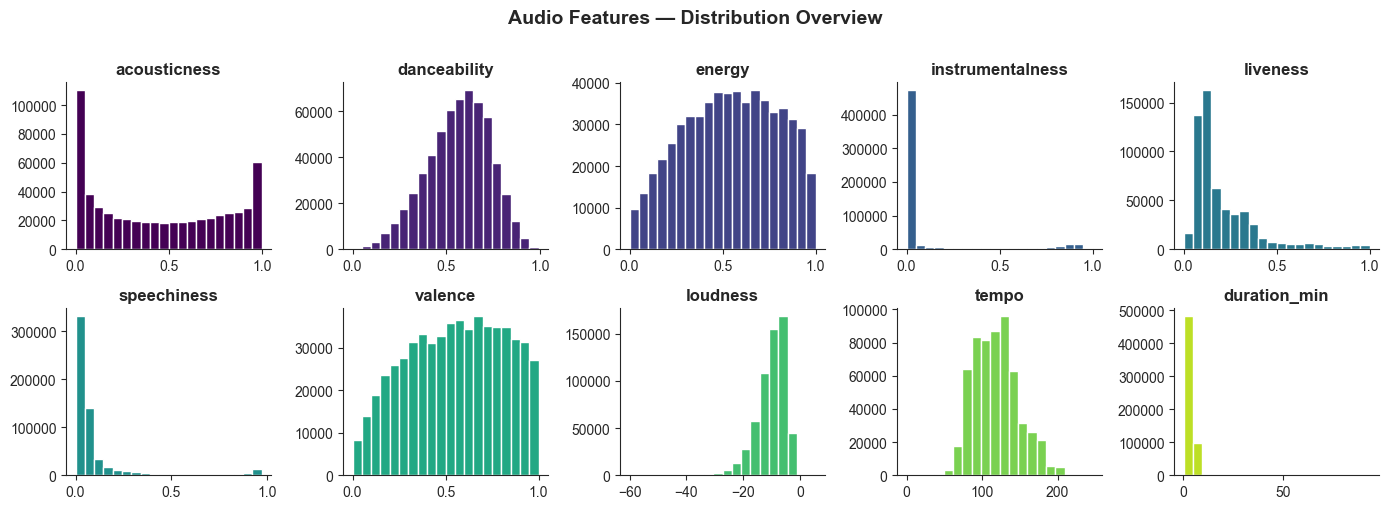

In [122]:
features_list_all = [
    'acousticness', 'danceability', 
    'energy', 'instrumentalness',
    'liveness', 'speechiness', 'valence',
    'loudness', 'tempo', 'duration_min'
    ]

# --- Distribution of 0_1 audio features ---
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.flatten()

# Generate 7 evenly spaced colors from the viridis palette
colors = [plt.cm.viridis(i / len(features_list_all)) for i in range(len(features_list_all))]

for i, (feature, color) in enumerate(zip(features_list_all, colors)):
    axes[i].hist(tracks[feature].dropna(), bins=20,
                 color=color, edgecolor='white')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    sns.despine(ax=axes[i])

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Audio Features — Distribution Overview',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [123]:
# --- FEATURE CLASSIFICATION ---

# IQR cleaning (symmetric distributions)
iqr_features       = ['tempo']

# Log + IQR cleaning (right-skewed, positive distributions)
log_iqr_features   = ['loudness', 'duration_min']
# Since loudness values are negative, before log transform, a value shift is required
LOUDNESS_SHIFT = abs(tracks['loudness'].min())

# Untouched: bounded 0-1 by Spotify's design, no cleaning needed
untouched_features = ['acousticness', 'danceability', 'energy', 'liveness,'
                      'valence', 'speechiness', 'instrumentalness']

In [124]:
# --- FUNCTIONS DEFINITION ---

def apply_iqr(df, features, fence=1.5):
    """
    Removes rows where values fall outside the IQR-based bounds.
    Best for roughly symmetric distributions.
    
    Parameters:
        df       : input DataFrame
        features : list of column names to clean
        fence    : IQR multiplier (1.5 = standard, 3.0 = conservative)
    """
    mask = pd.Series([True] * len(df), index=df.index)

    for col in features:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - fence * IQR   # Lower Bound
        ub = Q3 + fence * IQR   # Upper Bound

        col_mask = (df[col] >= lb) & (df[col] <= ub)
        mask     = mask & col_mask

        print(f"  [IQR] {col}: bounds ({lb:.2f}, {ub:.2f}) "
              f"— removed {(~col_mask).sum()} rows")

    return df[mask]

# -----------------------------------------------------------

def apply_log_iqr(df, features, fence=1.5):
    """
    Applies log1p transformation before computing IQR bounds, then
    converts the threshold back to the original scale before filtering.
    Best for right-skewed, positive distributions.

    Parameters:
        df       : input DataFrame
        features : list of column names to clean
        fence    : IQR multiplier (1.5 = standard, 3.0 = conservative)
    """
    mask = pd.Series([True] * len(df), index=df.index)

    for col in features:
        log_col = np.log1p(df[col])   # transform to log scale

        Q1  = log_col.quantile(0.25)
        Q3  = log_col.quantile(0.75)
        IQR = Q3 - Q1

        # Compute bounds on log scale, then convert back to original scale
        lb = np.expm1(Q1 - fence * IQR)
        ub = np.expm1(Q3 + fence * IQR)

        col_mask = (df[col] >= lb) & (df[col] <= ub)
        mask     = mask & col_mask

        print(f"  [Log+IQR] {col}: bounds ({lb:.2f}, {ub:.2f}) "
              f"— removed {(~col_mask).sum()} rows")

    return df[mask]

# -----------------------------------------------------------

def apply_noise_filter(df, keywords, columns=['name']):
    """
    Removes rows where any of the given columns contain noise keywords.
    Useful for filtering out non-music tracks (e.g. sleep sounds, live
    recordings, medleys) that would distort audio feature analysis.

    Parameters:
        df       : input DataFrame
        keywords : list of strings to filter out (case-insensitive)
        columns  : list of column names to search in (default: ['name'])
    """
    # Build a single regex pattern by joining all keywords with OR operator
    # e.g. ['white noise', 'rain'] → 'white noise|rain'
    pattern = '|'.join(keywords)

    # Start with all rows marked as valid
    mask = pd.Series([True] * len(df), index=df.index)

    for col in columns:
        # Case-insensitive match — na=False treats missing values as no match
        col_mask = ~df[col].str.lower().str.contains(pattern, na=False)
        mask     = mask & col_mask

        print(f"  [Noise Filter] '{col}': removed {(~col_mask).sum()} rows")

    return df[mask]

In [125]:
# --- NOISE KEYWORDS ---
noise_keywords = [
    'white noise', 'brown noise', 'baby sleep', 'ocean waves',
    'rain sounds', 'meditation', 'shhh', 'ao vivo',
    'previa', 'medley', 'mixtape', 'concert'
]

In [126]:
# --- CLEANING FUNCTIONS CALLING ---

print("=" * 55)
print("  CLEANING PIPELINE")
print("=" * 55)

tracks_clean = tracks.copy()

# shift loudness to positive
tracks_clean['loudness'] = tracks_clean['loudness'] + LOUDNESS_SHIFT

print(f"\n→ Initial rows: {len(tracks_clean)}")

# --- 1. IQR on tempo ---
print("\n[1/3] IQR cleaning:")
tracks_clean = apply_iqr(tracks_clean, iqr_features, fence=1.5)

# --- 2. Log+IQR on loudness and duration_min ---
print("\n[2/3] Log + IQR cleaning:")
tracks_clean = apply_log_iqr(tracks_clean, log_iqr_features, fence=3)

# restore original loudness scale
tracks_clean['loudness'] = tracks_clean['loudness'] - LOUDNESS_SHIFT

# --- 3. Noise keyword filter ---
print("\n[3/3] Noise keyword filter:")
tracks_clean = apply_noise_filter(tracks_clean, noise_keywords, columns=['name'])

# --- untouched_features: no action needed ---

print("\n" + "=" * 55)
print(f"  DONE — Rows kept: {len(tracks_clean)} / {len(tracks)} "
      f"({len(tracks_clean) / len(tracks) * 100:.1f}%)")
print("=" * 55)

  CLEANING PIPELINE

→ Initial rows: 586672

[1/3] IQR cleaning:
  [IQR] tempo: bounds (34.52, 197.40) — removed 5709 rows

[2/3] Log + IQR cleaning:
  [Log+IQR] loudness: bounds (32.05, 78.34) — removed 3758 rows
  [Log+IQR] duration_min: bounds (0.50, 13.12) — removed 3057 rows

[3/3] Noise keyword filter:
  [Noise Filter] 'name': removed 4607 rows

  DONE — Rows kept: 569618 / 586672 (97.1%)


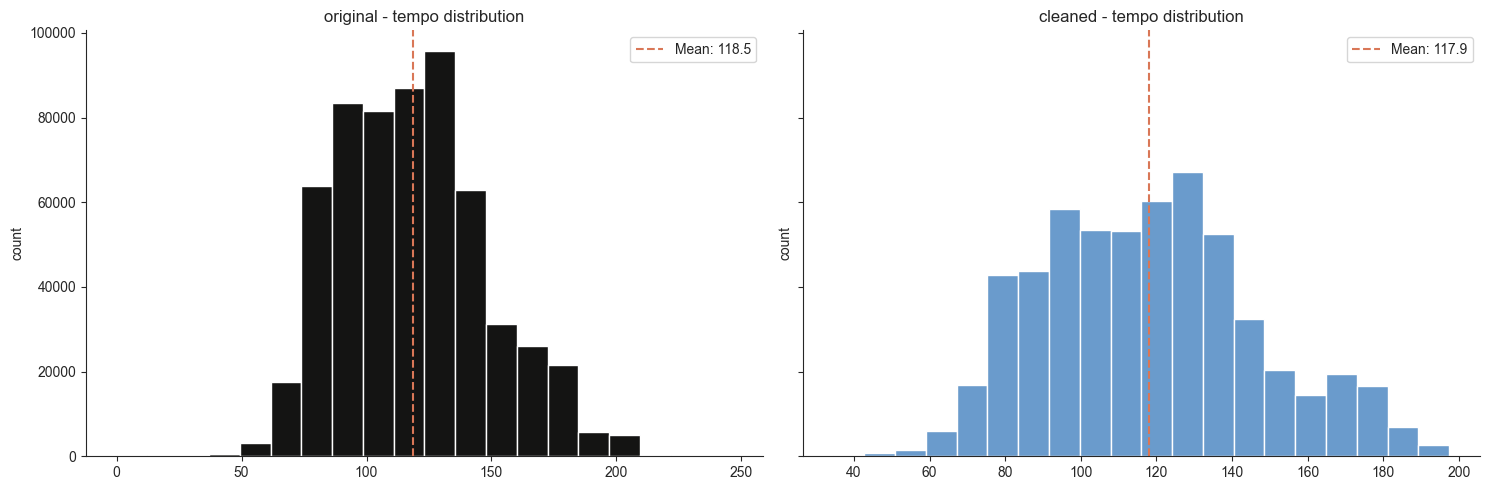

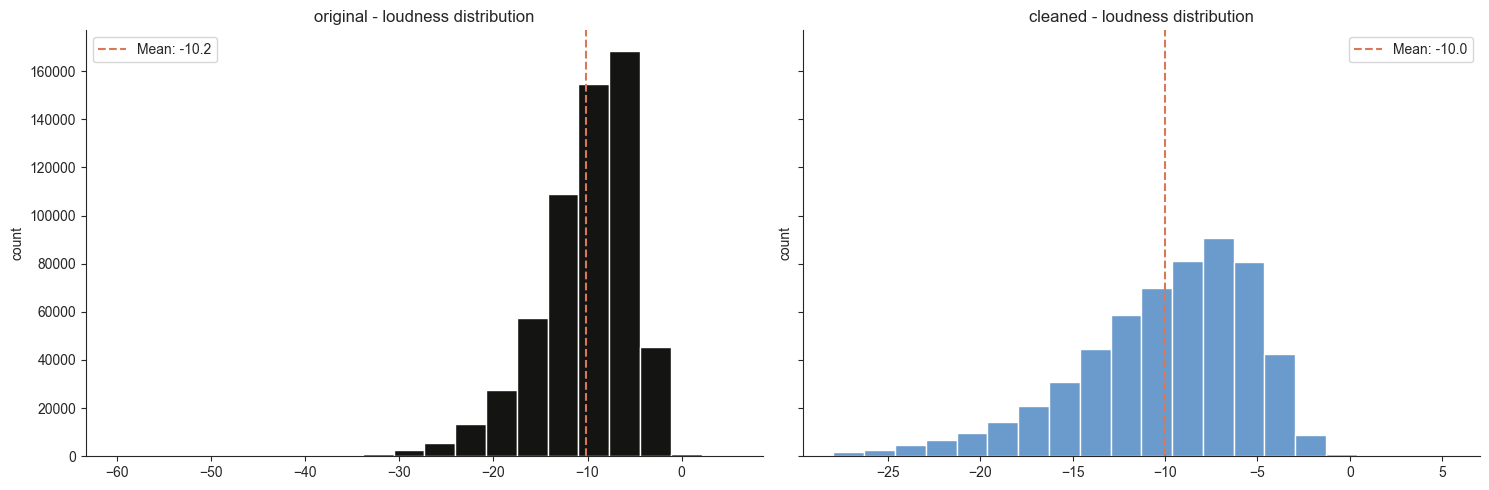

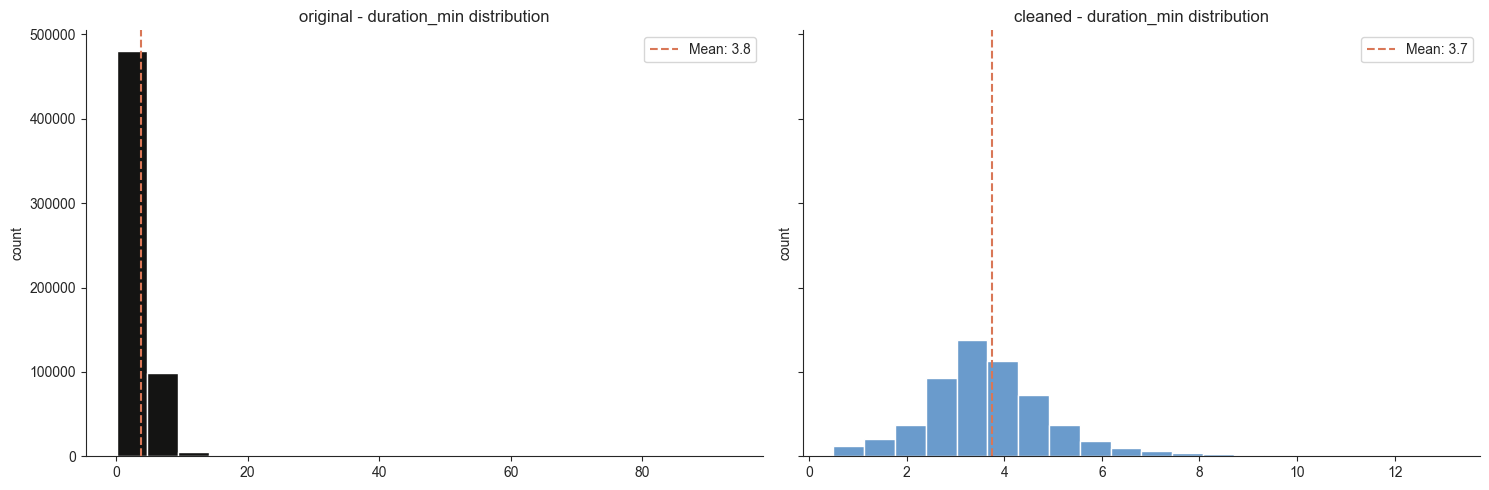

In [127]:
dfs = [tracks, tracks_clean]
labels = ['original', 'cleaned']
colors = ['#141413', '#6a9bcc']
columns = iqr_features + log_iqr_features

for column in columns:
    column = column
    fig, axes = plt.subplots(1, 2, figsize = (15, 5), sharey=True)

    for ax, df, label, color in zip(axes, dfs, labels, colors):
        ax.hist(df[column], bins = 20, color = color, edgecolor = 'white')
        ax.set_title(f"{label} - {column} distribution", fontsize = 12)
        ax.set_xlabel('')
        ax.set_ylabel('count')
        ax.axvline(df[column].mean(), color = '#d97757', linestyle='--', linewidth=1.5, label=f'Mean: {df[column].mean():.1f}')
        ax.legend()
        sns.despine(ax=ax)
    
    plt.tight_layout()
    plt.show()

**TEMPORAL ANALYSIS**

In [128]:
# Extract year
tracks_clean['year'] = tracks_clean['release_date'].dt.year

# Check for years with very few tracks
tracks_clean.groupby('year')['id'].size().sort_values()

year
1900        1
1922      285
1924      608
1923      647
1925      869
        ...  
1996    11782
1997    12071
1999    12101
1998    12170
2020    13690
Name: id, Length: 101, dtype: int64

In [129]:
# Only 1 record dated 1900 -> remove this record from the dataset
tracks_clean = tracks_clean[tracks_clean['year'] > 1900]

# Verify the filtering
print("Min year after filtering:", tracks_clean['year'].min())

Min year after filtering: 1922


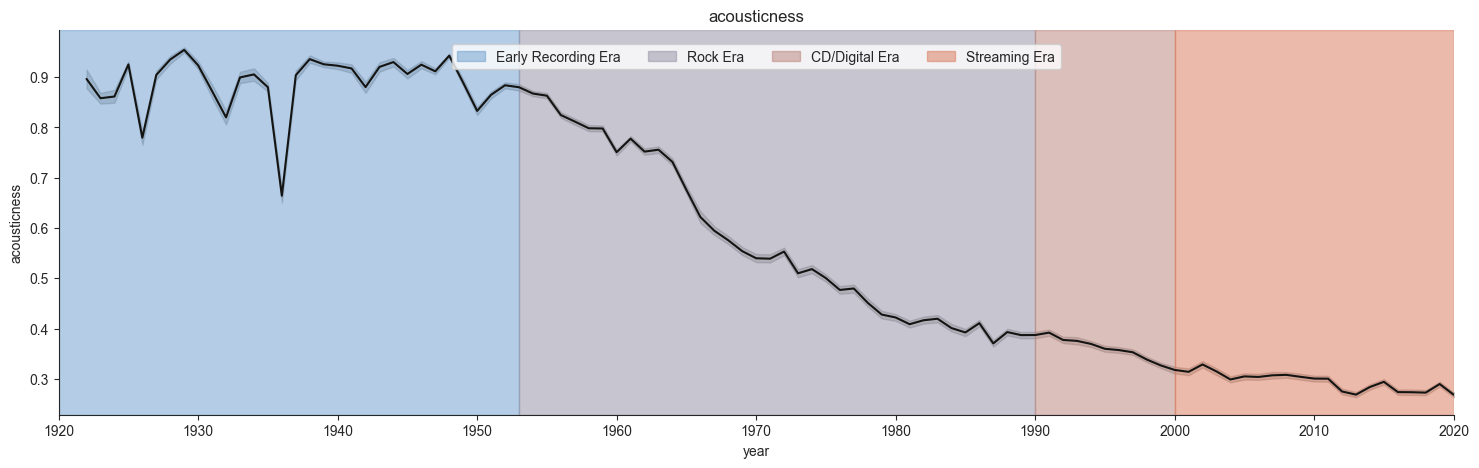

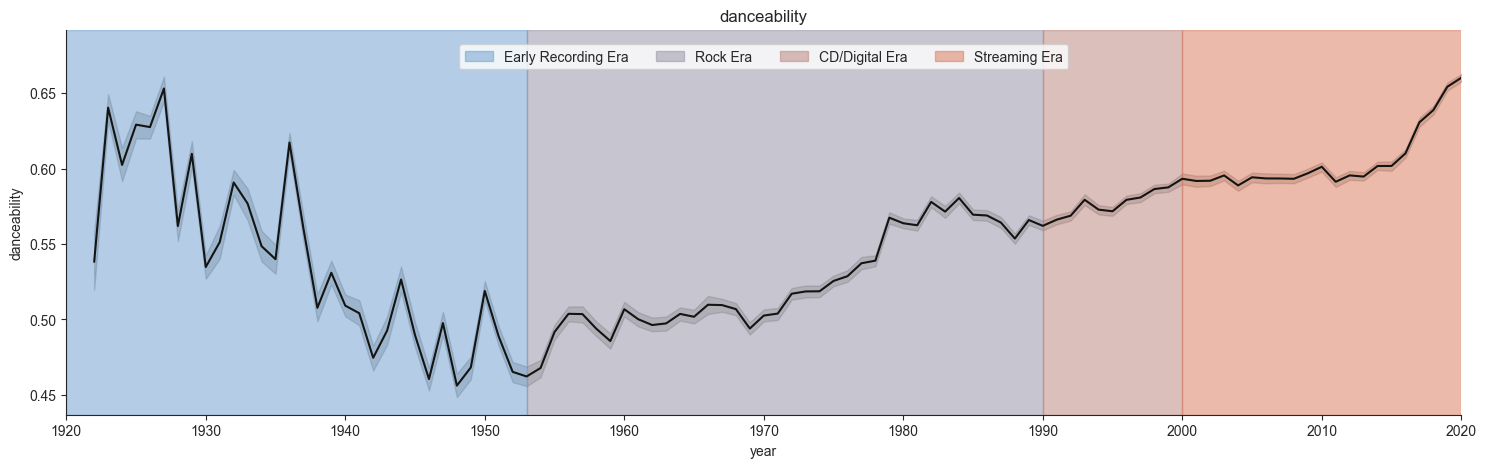

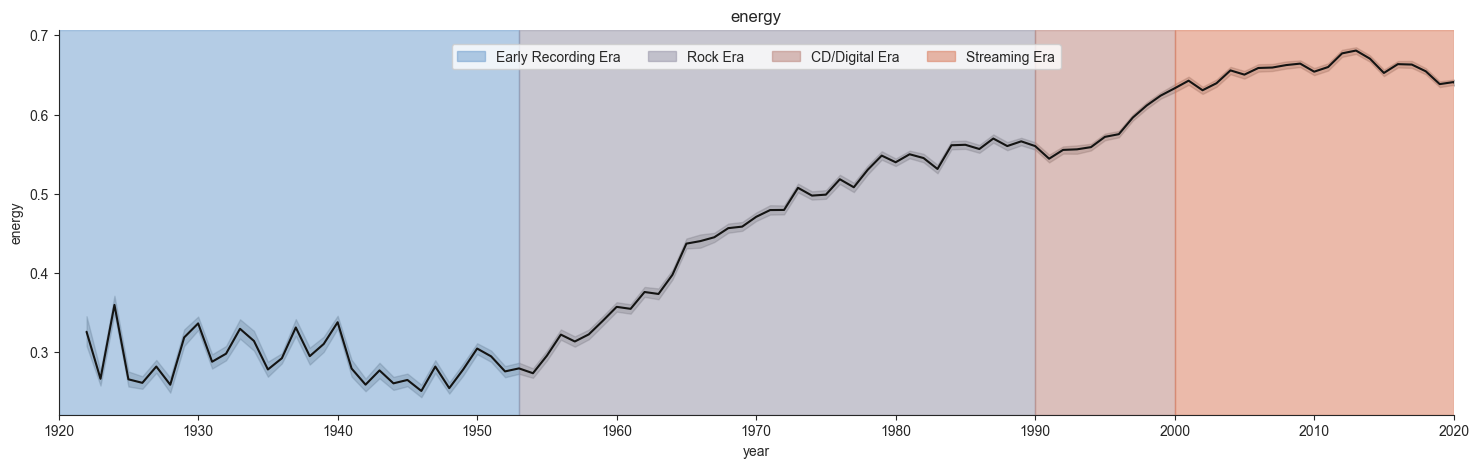

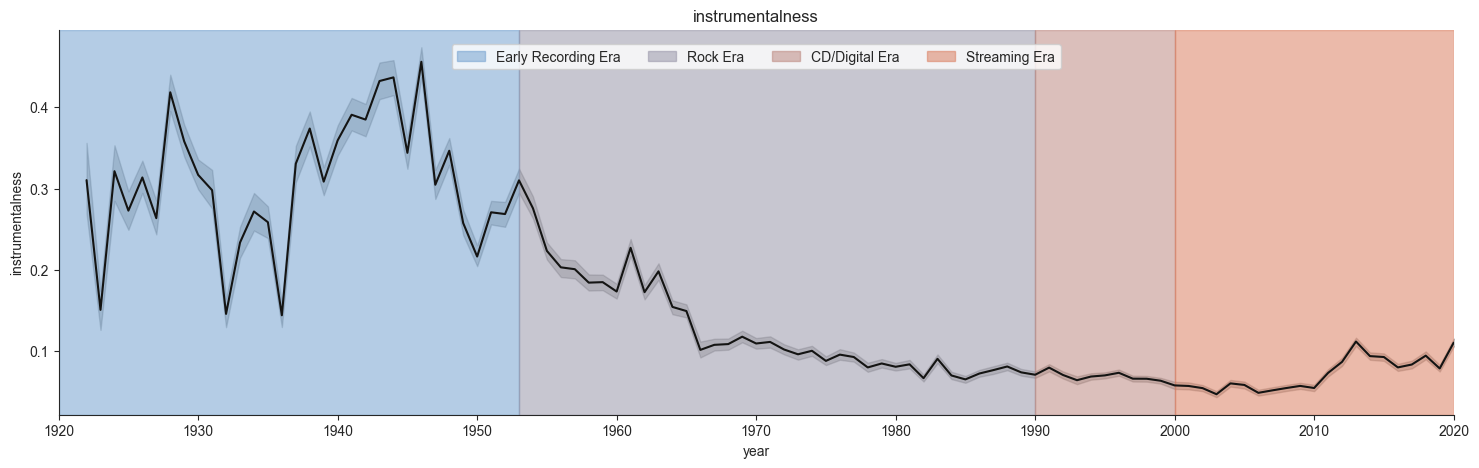

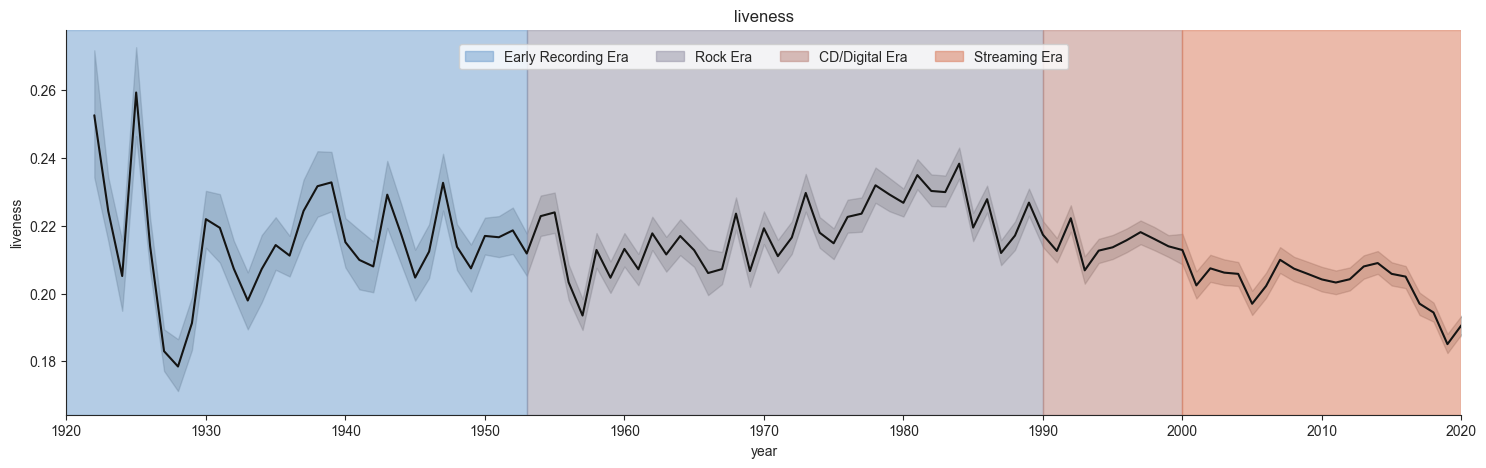

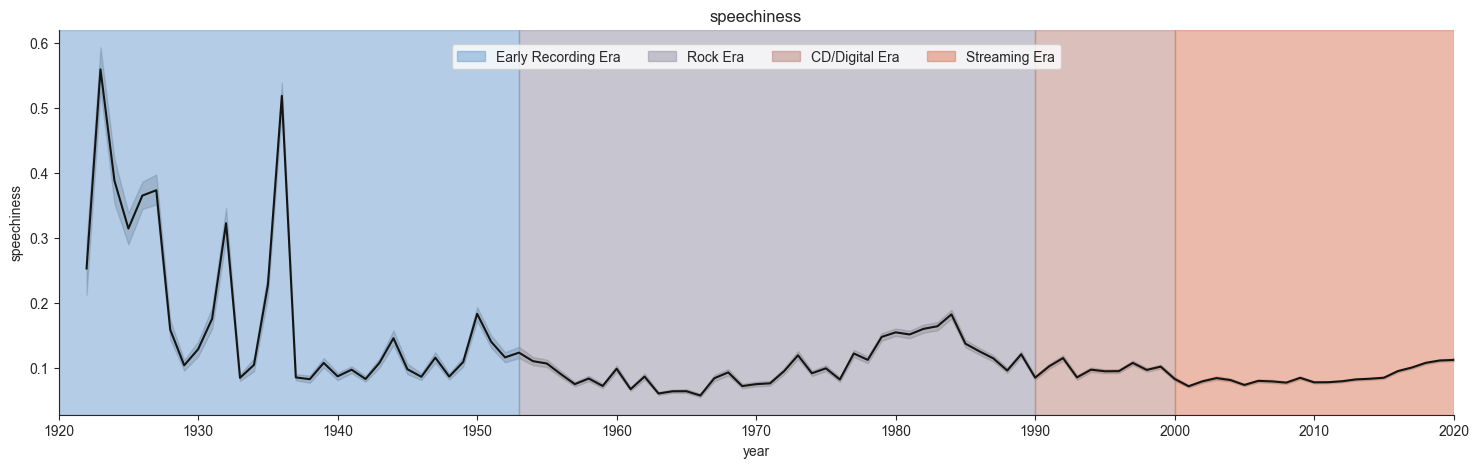

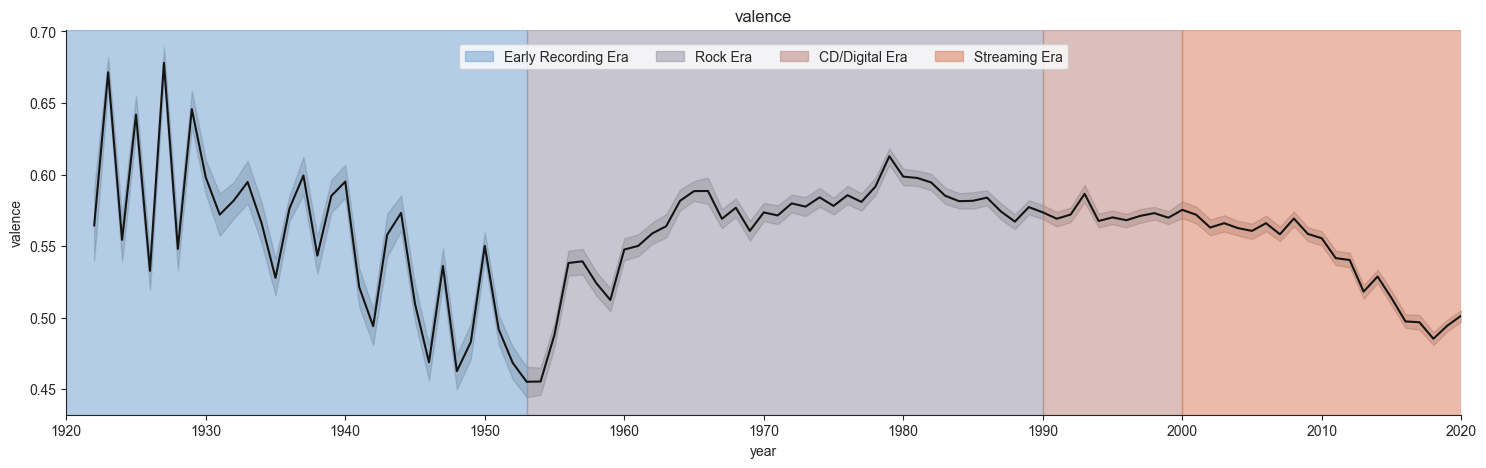

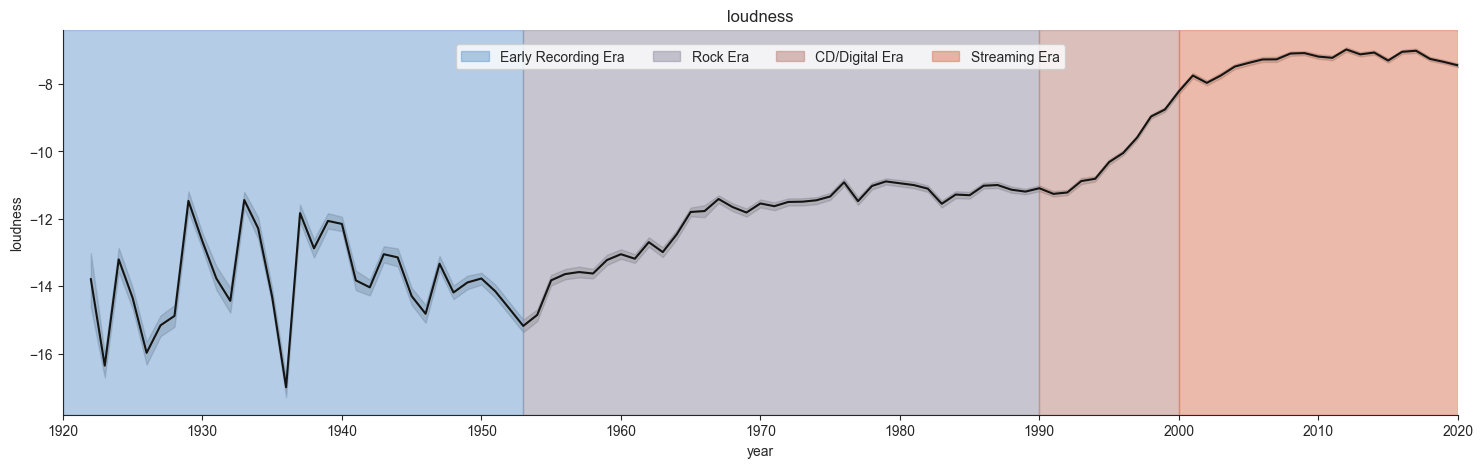

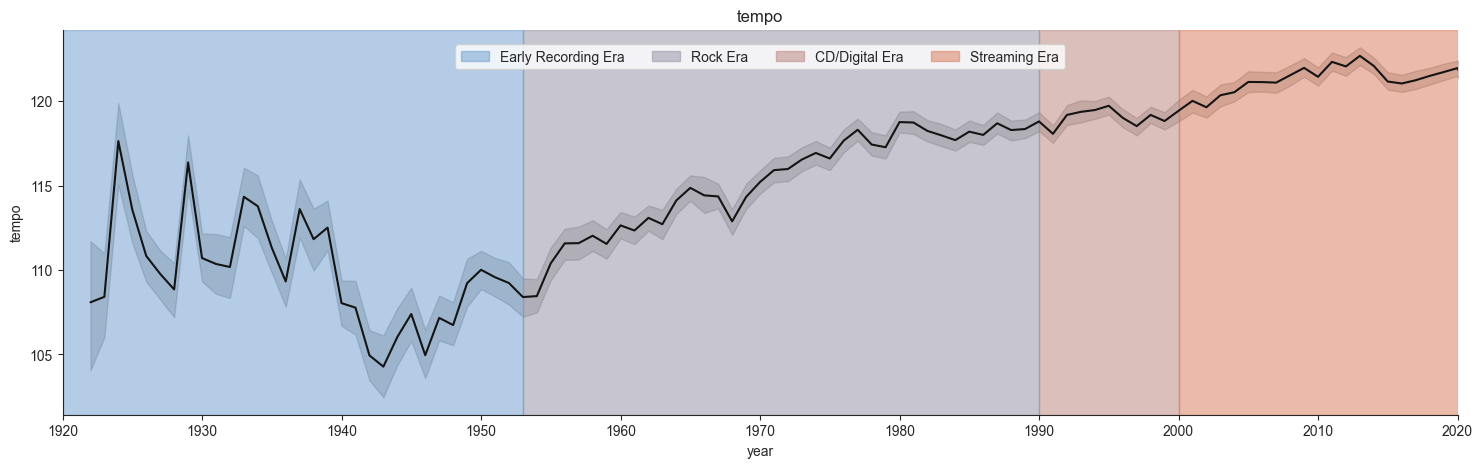

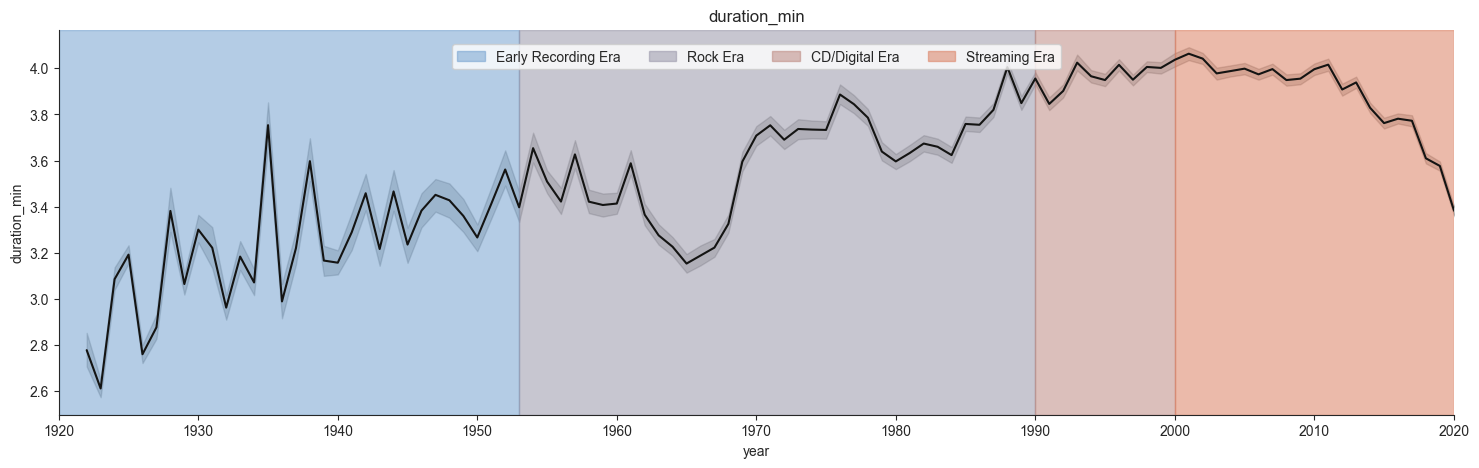

In [130]:
# Eras definition
eras = [
    (1920, 1953, '#6a9bcc', 'Early Recording Era'),
    (1953, 1990, '#918fa3', 'Rock Era'),
    (1990, 2000, '#b98178', 'CD/Digital Era'),
    (2000, 2020, '#d97757', 'Streaming Era'),
]

for f in features_list_all:
    fig, ax = plt.subplots(figsize = (18, 5))
    
    # Plot the feature (single color)
    sns.lineplot(tracks_clean[tracks_clean['year'] >= 1920], 
                 x='year', y=f, color='#141413', ax=ax)

    # Shaded era regions
    for start, end, color, label in eras:
        ax.axvspan(start, end, alpha=0.5, color=color, label=label)

    ax.set_title(f)
    ax.set_xlim(1920, 2020)
    ax.set_xticks(range(1920, 2021, 10))
    ax.legend(
    loc='upper center',        # ancora la legend in alto al centro
    bbox_to_anchor=(0.5, 0.98), # (50% x, leggermente sopra il plot)
    ncols=4,                   # 4 categorie = 4 colonne orizzontali
    fontsize=10
    )
    sns.despine()

plt.show()

### 🎵 Temporal Feature Analysis — Key Observations

Analyzing the evolution of audio features from 1920 to 2020, two clearly
opposed groups emerge:

| Trending UP ↑ | Trending DOWN ↓ |
|---|---|
| Loudness | Acousticness |
| Energy | Instrumentalness |
| Danceability | Valence (post-1980) |
| Tempo | |

This mirror pattern is not accidental — the two groups are deeply interconnected,
and the **Loudness War** appears to be a key driver of these diverging trends.

---

#### 🔊 The Loudness War as a Causal Engine

The Loudness War describes the progressive increase in mastering loudness
observed from the 1950s onward, accelerating sharply after 2000 with the rise
of digital production. Louder masters are achieved through **heavy dynamic
compression**, and this has measurable consequences on other audio features:

- **Energy increases** — compression raises the perceived intensity of a track
  by reducing the gap between quiet and loud moments
- **Acousticness decreases** — acoustic instruments naturally have wide dynamic
  range and are the most penalized by compression; electric and synthetic sounds
  are more compression-resilient
- **Instrumentalness decreases** — heavily compressed mixes tend to push vocals
  forward, as the human voice sits well in compressed frequency ranges

In other words, loudness is not just *correlated* with the other features —
it may be a **causal driver** of the trends observed across the entire dataset.

---

#### 📉 Valence: The Odd One Out

Valence (Spotify's measure of musical "happiness" or positivity) follows a
distinct pattern that does not align cleanly with either group:

- **High in the 1920s**, reflecting the upbeat, dance-oriented music of the era
- **Sharp drop toward 1952**, coinciding with post-war cultural shifts
- **Recovery through the Rock Era** (peaking ~1975–1980)
- **Steady decline through the Streaming Era**, reaching its lowest point near 2020

This divergence is notable: while music became progressively **louder and more
energetic**, it simultaneously became **emotionally darker**. This suggests that
sonic intensity and emotional positivity are increasingly decoupled in modern
production — a trend consistent with academic research on the emotional content
of contemporary pop music.

> 💡 *Valence deserves further investigation as a standalone dimension of
> musical evolution, independent of the loudness-driven dynamics.*

---

#### 🎸 The 1950s Inflection Point

Almost every feature displays a clear and sharp trend change at the
**Early Recording → Rock Era boundary (~1953)**. This inflection is historically
grounded:

- Electric amplification became the industry standard
- Magnetic tape recording replaced direct-to-disc, enabling studio editing
- The rise of Rock & Roll introduced a new production culture centered on
  rhythm, volume, and studio craft

This moment represents a **structural break** in the dataset and serves as a
natural anchor for the narrative of how music production evolved.

---

#### 🔇 Liveness: A Stable Control Variable

Unlike all other features, **liveness remains essentially flat** throughout the
entire century, oscillating in a narrow band between 0.18 and 0.27.

This stability is analytically valuable: it confirms that Spotify's algorithm
detects "live recording" characteristics consistently across eras, meaning
liveness is **not a confounding variable** in the trends observed for other
features. It can be safely set aside in further correlation analysis.

---

#### ➡️ Next Steps

The visual patterns identified above will be quantified through:
1. A **correlation matrix** on year-aggregated feature means, to confirm the
   two-group structure with Pearson coefficients
2. **Scatter plots** of yearly means (loudness vs. each feature, colored by era),
   to explore the causal relationship between the Loudness War and the
   evolution of other audio dimensions

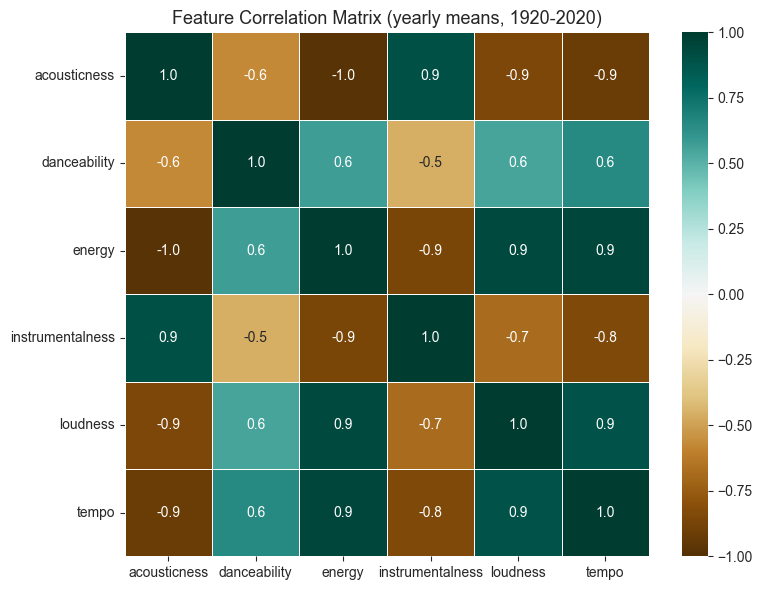

In [131]:
# Create a list of features that appear correlated

features_list_corr = [
                    'acousticness', 'danceability', 
                    'energy', 'instrumentalness',
                    'loudness', 'tempo'
                    ]


# Compute yearly means for all features
yearly_means = tracks_clean.groupby('year')[features_list_corr].mean()

# Correlation matrix on the yearly trends
corr_matrix = yearly_means.corr()


# Plotting the heatmap
fig, ax = plt.subplots(figsize = (8, 6))

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".1f",
    cmap = 'BrBG',
    vmin = -1, vmax = 1,   # fix color scale to full range
    linewidths = 0.5,      # add subtle grid lines
    ax = ax
)

ax.set_title('Feature Correlation Matrix (yearly means, 1920-2020)', 
             fontsize = 13)

plt.tight_layout()
plt.show()

#### 🔗 Feature Correlation Analysis

The correlation matrix on yearly means (1920–2020) confirms with strong
numerical evidence the two-group structure identified visually:

**The "acoustic" group** — acousticness acts as an anchor, negatively correlated
with every feature in the opposing group:
- acousticness ↔ energy: **-1.0**
- acousticness ↔ loudness: **-0.9** | acousticness ↔ tempo: **-0.9**
- acousticness ↔ danceability: **-0.6**

**The "electric/digital" group** — all internally consistent and positive:
- energy ↔ loudness: **0.9** | energy ↔ tempo: **0.9**
- loudness ↔ tempo: **0.9** | danceability ↔ tempo: **0.7**

**Instrumentalness** occupies a nuanced position: it correlates positively with
acousticness (0.9) but negatively with energy (-0.9) and loudness (-0.7).
This reflects a distinct historical dynamic — early instrumental music was
acoustic and quiet, a different phenomenon from the Loudness War.

> ➡️ *Next: scatter plots of yearly means (loudness vs. each feature, colored
> by era) to visualize the causal structure behind these correlations.*

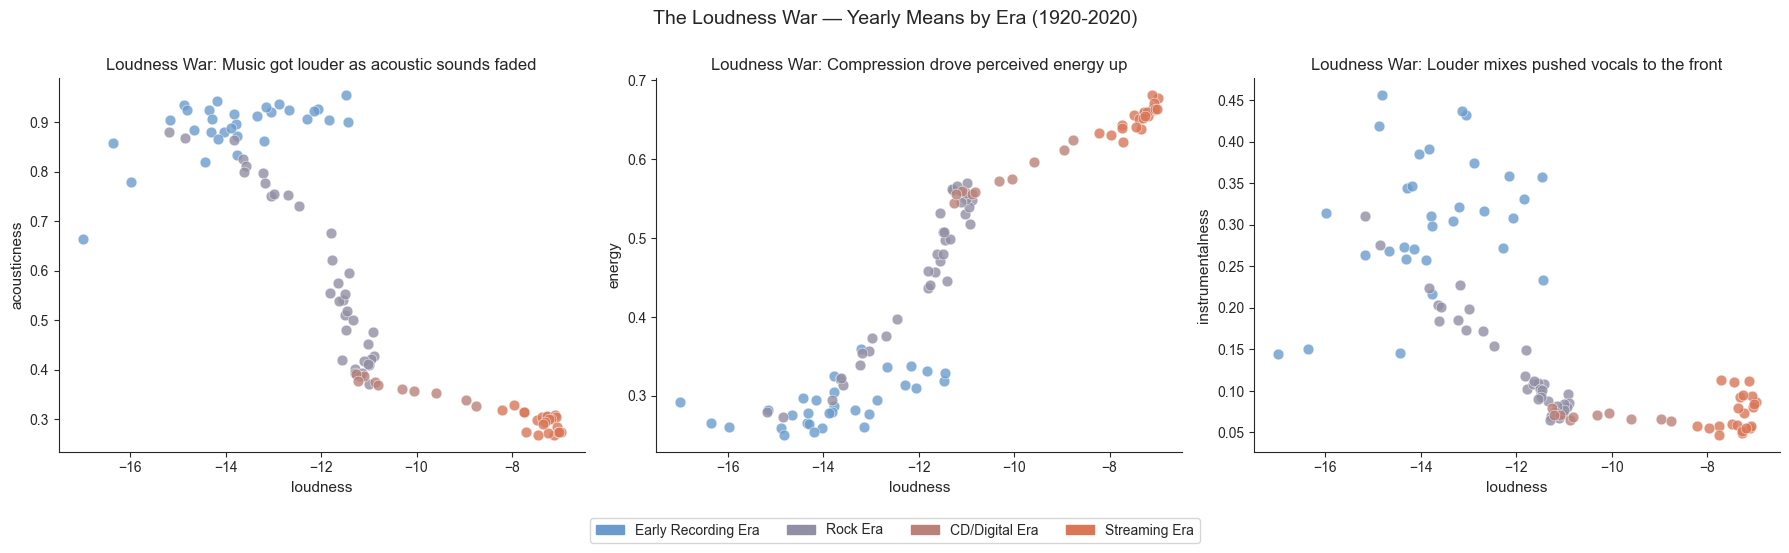

In [132]:
import matplotlib.patches as mpatches

# Era color mapping — reusing your existing era definitions
era_colors = {
    'Early Recording Era': '#6a9bcc',
    'Rock Era':            '#918fa3',
    'CD/Digital Era':      '#b98178',
    'Streaming Era':       '#d97757',
}

def get_era(year):
    """Assign an era label to a given year."""
    if year < 1953:
        return 'Early Recording Era'
    elif year < 1990:
        return 'Rock Era'
    elif year < 2000:
        return 'CD/Digital Era'
    else:
        return 'Streaming Era'

# Add era column to yearly_means
yearly_means['era'] = yearly_means.index.map(get_era)

# --- Plot setup ---
pairs = [
    ('loudness', 'acousticness', 'Loudness War: Music got louder as acoustic sounds faded'),
    ('loudness', 'energy',       'Loudness War: Compression drove perceived energy up'),
    ('loudness', 'instrumentalness', 'Loudness War: Louder mixes pushed vocals to the front'),
]

fig, axes = plt.subplots(1, 3, figsize = (18, 5))
fig.suptitle('The Loudness War — Yearly Means by Era (1920-2020)', 
             fontsize = 14, y = 1)

for ax, (x_feat, y_feat, subtitle) in zip(axes, pairs):
    for era, color in era_colors.items():
        # Filter rows belonging to this era
        era_data = yearly_means[yearly_means['era'] == era]
        ax.scatter(
            era_data[x_feat],
            era_data[y_feat],
            color = color,          # dot color from the era_colors dict
            alpha = 0.8,            # slight transparency
            edgecolors = 'white',   # thin white border on each dot
            linewidths = 0.4,
            s = 60,                 # dot size
            label = era             # used later by the legend
        )

    ax.set_xlabel(x_feat, fontsize = 11)
    ax.set_ylabel(y_feat, fontsize = 11)
    ax.set_title(subtitle, fontsize = 12)
    sns.despine(ax = ax)

# Single shared legend below all plots
handles = [mpatches.Patch(color = c, label = e) for e, c in era_colors.items()]     # Build one colored square per era manually
fig.legend(handles = handles, loc = 'lower center', ncols = 4,                      # Place it below all 3 plots, centered
           bbox_to_anchor = (0.5, -0.08), fontsize = 10)

plt.tight_layout()
plt.show()

### 📊 Scatter Plot Analysis — Loudness War Relationships

#### 🎙️ Early Recording Era — Controlled Heterogeneity
The wide dispersion of the blue cluster is historically meaningful, not noise:
- **Genuine diversity** — no dominant sound yet; jazz, blues, classical, spoken
  word and folk coexisted with very different audio profiles
- **Inconsistent recording technology** — early microphones and studio
  conditions varied enormously; Spotify's algorithms (trained on modern audio)
  may compute features less reliably on century-old recordings
- **Small yearly sample sizes** — fewer tracks per year means individual
  outliers have a disproportionate impact on the yearly mean

> 💡 *The Early Recording Era represents the "experimentation phase" before the
> industry converged on a dominant production formula.*

---

#### 📉 Loudness vs Acousticness — An L-Shape, Not a Line
The relationship is non-linear: acousticness drops steeply as loudness
increases from -16 to -12 dB, then flattens near 0.3. This is a **floor
effect** — once electric and digital production took over, acousticness could
not decrease further regardless of additional loudness gains.

#### 📈 Loudness vs Energy — The Clearest Signal
The most linear of the three plots. Eras stack almost perfectly along a
diagonal, providing the strongest visual confirmation of the Loudness War
mechanism: compression → louder signal → higher perceived energy, consistently
across all decades.

#### 🎸 Loudness vs Instrumentalness — Two Different Stories
The most scattered of the three. Early Recording Era dots sit high on
instrumentalness but spread across loudness values — instrumentalness in that
era was driven by acoustic ensemble music with no vocal dominance, an entirely
**different mechanism** from the modern era, where its decline is driven by
loud mixes pushing vocals to the front.

### Mode and Key temporal analysis

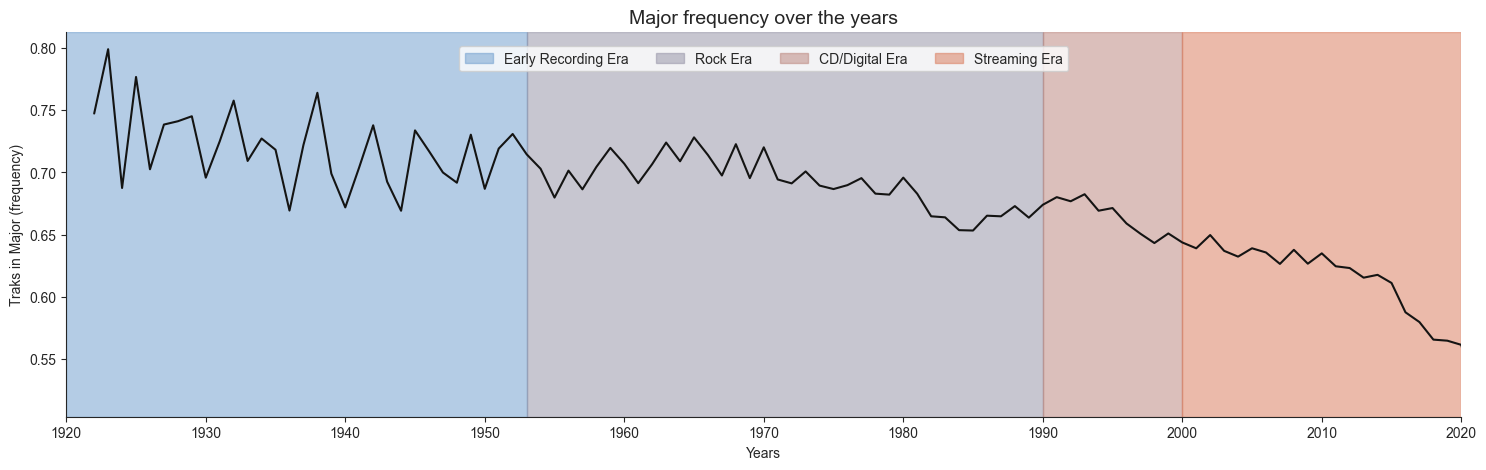

In [ ]:
f_maj = (tracks_clean['mode_name'] == 'Major').groupby(tracks_clean['year']).mean()

fig, ax = plt.subplots(figsize = (18, 5))

# Era shading
for start, end, color, label in eras:
    ax.axvspan(start, end, alpha = 0.5, color = color, label = label)

# Valence line
sns.lineplot(data = f_maj, 
             ax = ax, color = '#141413', linewidth = 1.5)

ax.set_title('Major frequency over the years', fontsize = 14)
ax.set_ylabel('Tracks in Major (frequency)')
ax.set_xlabel('Years')
ax.set_xlim(1920, 2020)
ax.set_xticks(range(1920, 2021, 10))
ax.legend(
loc='upper center',             # ancora la legend in alto al centro
bbox_to_anchor=(0.5, 0.98),     # (50% x, leggermente sopra il plot)
ncols=4,                        # 4 categorie = 4 colonne orizzontali
fontsize=10
)
sns.despine()

plt.show()


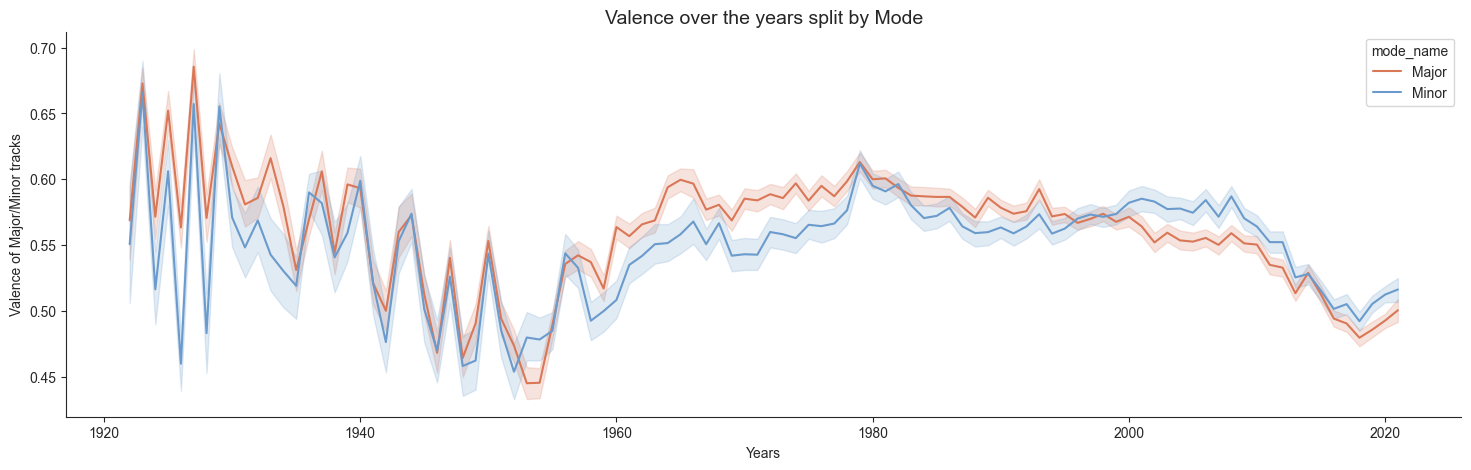

In [156]:
fig, ax = plt.subplots(figsize=(18, 5))

sns.lineplot(data=tracks_clean, x='year', y='valence',
             hue='mode_name', palette=['#d97757', '#6a9bcc'],
             ax=ax)

ax.set_title('Valence over the years split by Mode', fontsize = 14)
ax.set_ylabel('Valence of Major/Minor tracks')
ax.set_xlabel('Years')
sns.despine()

### Mode Analysis — Key Findings

#### Setup
To investigate the valence decline observed post-1980, mode (Major/Minor) was
analyzed as a potential structural driver. Two questions were asked:
1. Has the proportion of Major-mode tracks changed over time?
2. Does valence decline differently depending on mode?

---

#### Finding 1 — Major-mode music has been in continuous decline
The proportion of Major tracks dropped from ~75% in the 1920s to ~55% by 2020,
with the decline accelerating in the Streaming Era. This confirms a long-term
compositional shift toward minor-mode music across the entire century.

---

#### Finding 2 — But mode alone does not explain the valence decline
When valence is plotted separately for Major and Minor tracks, both lines follow
**identical trajectories** — same W-shape, same inflection points, same
streaming-era collapse. The gap between them remains small and stable (~0.03–0.05).

This rules out a purely compositional explanation: it is not simply that
*more minor tracks* are pulling the average down. Even Major-key music
is becoming emotionally darker over time.

---

#### Finding 3 — Major/Minor emotional distinction is eroding
By 2020, the valence gap between Major and Minor tracks has nearly disappeared.
A structural musical feature that traditionally carried strong emotional
signal is losing its perceptual relevance in modern production.

---

#### Interpretation
The valence decline is **systemic**, not compositional. It reflects broader
cultural and production shifts — likely related to genre evolution (rise of
hip-hop, dark pop, lo-fi), lyrical tone, and possibly streaming platform
dynamics — that affect emotional tone independently of harmonic mode.

In [142]:
tracks_clean['decade'] = (tracks_clean['year'] // 10) * 10

In [143]:
counts = tracks_clean.groupby(['decade', 'key_name']).size()
key_freq_y = counts / counts.groupby(level='decade').transform('sum')

# Pivot to matrix form for heatmap
key_pivot = key_freq_y.unstack(level='key_name').T  # keys as rows, decades as columns
key_pivot

decade,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
key_name,,,,,,,,,,,
A,0.078200,0.082377,0.081556,0.071930,0.099803,0.126199,0.129066,0.124377,0.119132,0.102660,0.081800
A♯,0.077788,0.087033,0.096509,0.087985,0.073192,0.054794,0.055072,0.059664,0.058935,0.063491,0.070511
B,0.051310,0.047049,0.051948,0.037131,0.041583,0.057598,0.067500,0.066936,0.077287,0.085503,0.091376
C,0.114693,0.111843,0.115751,0.136775,0.137966,0.135624,0.138409,0.130547,0.122270,0.116123,0.112192
C♯,0.129099,0.093296,0.077207,0.064666,0.052718,0.046978,0.057697,0.064958,0.073171,0.093448,0.122121
D,0.071889,0.086552,0.093411,0.095100,0.116572,0.138827,0.126553,0.121579,0.114474,0.097942,0.083867
D♯,0.086432,0.071859,0.069641,0.066758,0.051819,0.031794,0.029496,0.026799,0.028412,0.032277,0.030896
E,0.047057,0.058129,0.064518,0.055996,0.076458,0.092878,0.092007,0.089468,0.087548,0.079196,0.070259
F,0.114968,0.117061,0.109019,0.132799,0.121854,0.094487,0.085675,0.082912,0.080919,0.077821,0.080641


Text(0.5, 58.7222222222222, 'Decades')

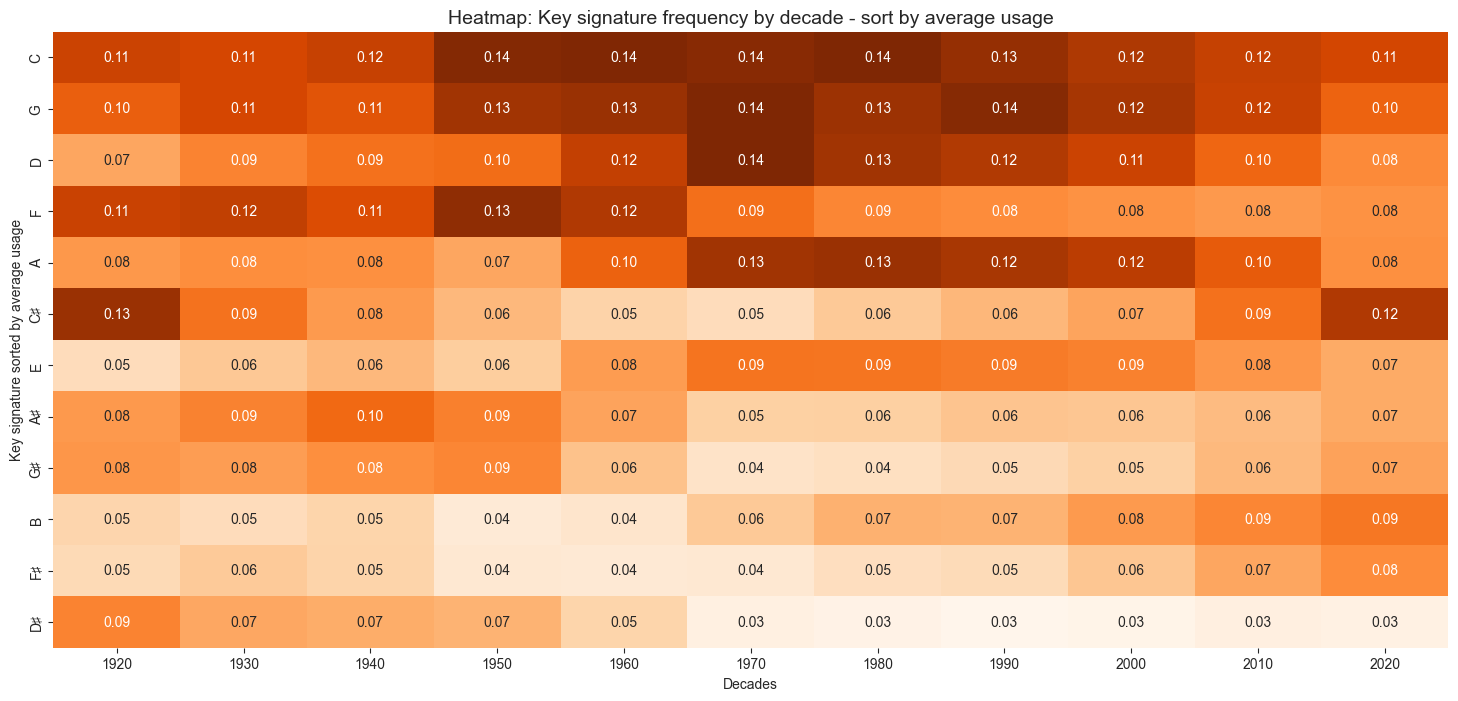

In [157]:
key_order = key_pivot.mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(18, 8))  # wider
sns.heatmap(key_pivot.loc[key_order],
ax=ax,
annot = True,
fmt = ".2f",
cmap='Oranges',
cbar=False
)

ax.set_title('Heatmap: Key signature frequency by decade - sort by average usage', fontsize = 14)
ax.set_ylabel('Key signature sorted by average usage')
ax.set_xlabel('Decades')

### Key Distribution Over Time — Findings

#### Setup
Track proportions per key were computed decade by decade and visualized
as a heatmap (rows sorted by mean dominance). This reveals which keys
have historically dominated Western popular music and how preferences
shifted across eras.

---

#### Finding 1 — Plain keys dominate over sharps/flats
The top 4 rows (C, G, D, F) are all natural keys, while sharped/flatted
keys (C#, A#, G#, D#, F#) consistently cluster at the bottom. This is
not accidental — natural keys are physically easier to play on guitar
and piano, the two instruments that have driven popular music composition
for a century. The bias toward "guitarist-friendly" keys is structural.

---

#### Finding 2 — C, G, D form a stable dominant triad from the 1950s onward
From the 1950s through the 1990s, C, G and D are the three most used keys
with proportions consistently between 0.12–0.14. These three keys form
the core of the circle of fifths and share many common chords, making
them the natural gravitational center of Western pop and rock harmony.

---

#### Finding 3 — F declines, A rises: a genre shift in the 1960s–70s
F is strongly represented in the early eras (0.11–0.13 up to the 1950s)
but declines sharply from the 1960s onward (0.08–0.09), while A rises
from 0.07 in the 1950s to 0.13 by the 1970s and holds there.
This likely reflects the rise of electric guitar-driven rock: A and E
are the most natural keys for guitar (open tuning, power chords), while
F is notoriously awkward on guitar due to the barre chord requirement.

---

#### Finding 4 — C# anomaly in the 1920s and resurgence in 2020
C# shows an unusually high proportion in the 1920s (0.13) — likely an
artifact of small sample size and the predominance of brass-heavy jazz
and big band arrangements, where flat/sharp keys are more natural for
wind instruments. Its resurgence in 2020 (0.12) is more likely driven
by digital production: in a DAW, key has no physical constraint, so
producers are freer to use any key that fits the vocal range.

---

#### Musical Interpretation
The overall pattern tells a coherent story: key choice in popular music
has historically been constrained by **instrument ergonomics** rather
than aesthetic preference. The dominance of C, G, D and the decline of F
map almost perfectly onto the rise of the guitar as the central instrument
of pop music. The partial flattening of these differences in the streaming
era likely reflects the shift toward digital production, where the
physical constraints of any instrument no longer apply.